# SPEARMAN CODE

# First, run the code below for each league and the specific data_type you want. The output will be all figures for the spearman coefficient for that league and data_type. You will also be prepared to get the CSV with the combined leagues for the data_type you want, which can be done in the next code block.

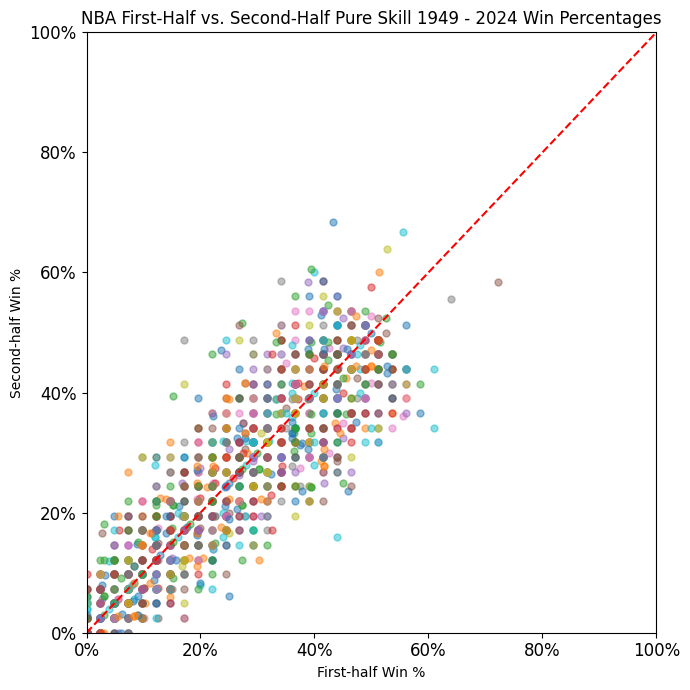

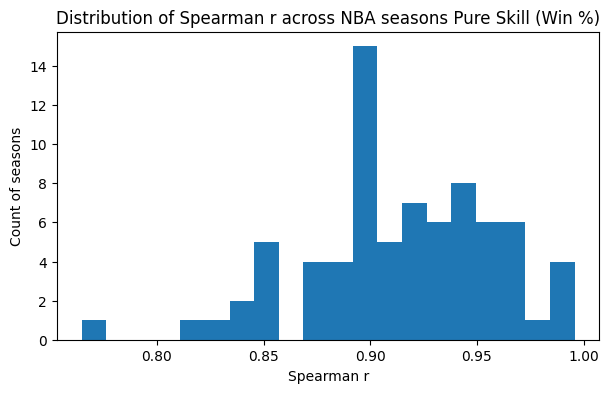


r value meanings:
r closer to 1: first half ranks are very predictive of second half ranks
r closer to 0: first half ranks are NOT very predictive of second half ranks
r negative: reverse tendency. high first half ranks predict low second half ranks, and vice versa


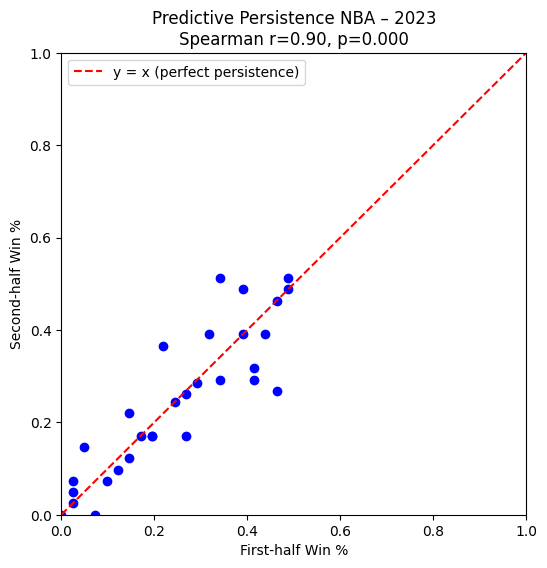

Saved NBA per-season Spearman stats to: /mnt/data/nba_spearman_by_season_pure_skill.csv


,season,n_teams,spearman_r,spearman_p
0,1949,17,0.884663,2.410114e-06
1,1950,11,0.952166,6.254560e-06
2,1951,10,0.902456,3.515764e-04
3,1952,10,0.945140,3.707957e-05
4,1953,9,0.764733,1.637769e-02
5,1954,8,0.902708,2.137647e-03
6,1955,8,0.879582,3.980559e-03
7,1956,8,0.951807,2.698078e-04
8,1957,8,0.970077,6.548559e-05
9,1958,8,0.994030,5.296154e-07


Saved NBA first/second-half team win% to: /mnt/data/nba_first_second_win_pct_pure_skill.csv


,league,season,team,first_half_win_pct,second_half_win_pct,n_first,n_second
0,NBA,1949,AND,0.375000,0.312500,32,32
1,NBA,1949,BAL,0.117647,0.088235,34,34
2,NBA,1949,BOS,0.000000,0.058824,34,34
3,NBA,1949,CHS,0.264706,0.323529,34,34
4,NBA,1949,DEN,0.000000,0.000000,31,31
5,NBA,1949,FWP,0.323529,0.264706,34,34
6,NBA,1949,INO,0.437500,0.406250,32,32
7,NBA,1949,MNL,0.411765,0.529412,34,34
8,NBA,1949,NYK,0.235294,0.470588,34,34
9,NBA,1949,PHA,0.088235,0.147059,34,34


In [7]:
# ============================================================
# Predictive Persistence Analysis (league-selectable) NEW CODE
# ============================================================

# 0) Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import matplotlib.ticker as mtick

# ------------------------------------------------------------
# 1) Load the dataset: (choose league + file)
# ------------------------------------------------------------

LEAGUE = "NBA"  # <-- set to "NBA", "NFL", or "MLB"
data_type = "pure_skill"  # <-- set to "coin_flip", "pure_skill", or "actual"

# ---- choose DATA_PATH from data_type ----
if data_type == "coin_flip":
    DATA_PATH = "/mnt/data/us_coin_flip_home_bias_v1.csv"
elif data_type == "pure_skill":
    DATA_PATH = "/mnt/data/us_combined_pure_skill.csv"
elif data_type == "actual":
    DATA_PATH = "/mnt/data/us_combined_data.csv"

# ---- detect pure-skill file name to switch win rule ----
USE_RESULT = ('pure_skill' in DATA_PATH.lower())

df = pd.read_csv(DATA_PATH)
df = df[df['league'] == LEAGUE]
df['date'] = pd.to_datetime(df['date'])

# ------------------------------------------------------------
# 2) Convert into "team-game" format
# We build a table where each original game row
# is viewed from one of the team's point of view.
# Then we can look at, for each team, a section in the table which
# represents their wins and losses throughout the season
# ------------------------------------------------------------

## Team1 Perspective ##
t1 = pd.DataFrame({
    'season': df['season'],
    'date': df['date'],
    'team': df['team1'],
    'opponent': df['team2'],
    'points_for': df['score1'],
    'points_against': df['score2'],
})
# add team's point differential for each game
t1['margin'] = t1['points_for'] - t1['points_against']
# add team's win flag for each game. 1 = win, 0 = loss
t1['win'] = (df['result'] == 1).astype(int) if USE_RESULT else (t1['margin'] > 0).astype(int)

## Team2 Perspective ##
t2 = pd.DataFrame({
    'season': df['season'],
    'date': df['date'],
    'team': df['team2'],
    'opponent': df['team1'],
    'points_for': df['score2'],
    'points_against': df['score1'],
})
# add team's point differential for each game
t2['margin'] = t2['points_for'] - t2['points_against']
# add team's win flag for each game 1 = win, 0 = loss
t2['win'] = (df['result'] == 0).astype(int) if USE_RESULT else (t2['margin'] > 0).astype(int)

# Combine both perspectives
# Make a single table with one row per team per game
# (each real game appears twice: once for each team’s perspective).

# stacks rows, and then reindexes the rows to go from row 0 to row N-1
team_games = pd.concat([t1, t2], ignore_index=True)
# reorders rows so they are grouped by season, then by team, then by date
# reindexes the rows to go from row 0 to row N-1, delete old row lab\
team_games = team_games.sort_values(['season','team','date']).reset_index(drop=True)

# ------------------------------------------------------------
# 3) Helper functions
# ------------------------------------------------------------

# define function which takes in the team games, and returns, for
# each season and team, the team's first-half and second-half win percentages
def compute_first_second_halves(team_games):
    rows = [] # initializes an empty list
    # for loop groups team_games by season and team, where
    # (season, team) is the current group key, and
    # grp is a DataFrame containing only that team's rows in the season
    for (season, team), grp in team_games.groupby(['season','team']):
        grp = grp.sort_values('date') # sorts grp by date
        n = len(grp)
        if n < 2: # if season has < 2 games, can't split into halves, so skip
            continue
        split = n // 2 # gives index at which to split the season into two halves
        first = grp.iloc[:split] # take first split rows as first half
        second = grp.iloc[split:]# take second split rows as second half
        if len(first) == 0 or len(second) == 0: # if n was 1, skip
            continue
        m1, m2 = first['win'].mean(), second['win'].mean() # mean = fraction of wins
        # store summary row for this (seaosn, team)
        rows.append({'season': season, 'team': team,
                     'first': m1, 'second': m2,
                     'n_games': n})
    # return the collected list of dictionaries into a DataFrame with cols
    # season, team, first, second, n_games
    return pd.DataFrame(rows)

# define function which plots first-half and second-half win percentage
# for all teams in one season
def plot_season_scatter(grp, season):
    # compute Spearman rank correlation and p_value between first half and second half win percentage
    r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
    plt.figure(figsize=(6,6)) # creates square figure
    plt.scatter(grp['first'], grp['second'], color='blue') # plots one point per team
    # draw y = x line
    xs = np.linspace(0, 1, 100)
    plt.plot(xs, xs, linestyle='--', color='red', label='y = x (perfect persistence)')
    # fix x and y axis to [0,1], label axes, title graph
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xlabel('First-half Win %')
    plt.ylabel('Second-half Win %')
    plt.title(f'Predictive Persistence {LEAGUE} – {season}\nSpearman r={r_s:.2f}, p={p_s:.3f}')
    plt.legend() # shows label on y = x line
    plt.show()

# define function which takes output of compute_first_second_halves (one row per team-season
# with 'first' and 'second' win percentages) and computes a per-season Spearman correlation.
def season_correlations(first_second_df):
    out = []  # collect one dict per season with Spearman stats
    for season, grp in first_second_df.groupby('season'):
        # Need variation and enough teams; otherwise correlation is undefined or meaningless
        if grp['first'].nunique() <= 1 or grp['second'].nunique() <= 1 or len(grp) < 3:
            continue
          # rank each array
        r_s, p_s = stats.spearmanr(grp['first'], grp['second'])
        out.append({
            'season': season,
            'n_teams': len(grp),
            'spearman_r': r_s,
            'spearman_p': p_s
        })
      # store stats for the season: number of teams,
      # spearman r-val (correlation between first half and second half win %
      # across teams in that season), p-val
    return pd.DataFrame(out).sort_values('season')


# ------------------------------------------------------------
# 4) Run predictive persistence analysis
# ------------------------------------------------------------

# get per team per season summaries
fs_win = compute_first_second_halves(team_games)
# give the summaries to the correlation helper
corr_win = season_correlations(fs_win)


# ------------------------------------------------------------
# 5) One combined plot with ALL seasons overlaid
#    Title format: "Predictive Persistence LEAGUE - [lowest season - highest season]"
# ------------------------------------------------------------

if not fs_win.empty:
    min_season = int(df.loc[df['league'].eq(LEAGUE), 'season'].min())
    max_season = int(df.loc[df['league'].eq(LEAGUE), 'season'].max())

    plt.figure(figsize=(7,7))
    # Overlay each season's points
    for season, grp in fs_win.groupby('season'):
        plt.scatter(grp['first'], grp['second'], alpha=0.5, s=25, label=str(season))

    # create plot
    xs = np.linspace(0, 1, 100)
    plt.plot(xs, xs, linestyle='--', color='red', label='y = x (perfect persistence)')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    ax = plt.gca()
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel('First-half Win %') # commented out since small for presentation
    plt.ylabel('Second-half Win %') # commented out since small for presentation
    # adjust title based on file
    if data_type == "coin_flip":
        plt.title(f'{LEAGUE} First-Half vs. Second-Half Pure Luck {min_season} - {max_season} Win Percentages')
    elif data_type == "pure_skill":
        plt.title(f'{LEAGUE} First-Half vs. Second-Half Pure Skill {min_season} - {max_season} Win Percentages')
    elif data_type == "actual":
        plt.title(f'{LEAGUE} First-Half vs. Second-Half {min_season} - {max_season} Win Percentages')
    # adjust title based on file
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 6) Histogram of Spearman correlations across seasons
# ------------------------------------------------------------

if not corr_win.empty:
    plt.figure(figsize=(7,4))
    plt.hist(corr_win['spearman_r'].dropna(), bins=20)
    # adjust title based on file
    if data_type == "coin_flip":
        plt.title(f'Distribution of Spearman r across {LEAGUE} seasons Pure Luck (Win %)')
    elif data_type == "pure_skill":
        plt.title(f'Distribution of Spearman r across {LEAGUE} seasons Pure Skill (Win %)')
    elif data_type == "actual":
        plt.title(f'Distribution of Spearman r across {LEAGUE} seasons (Win %)')
    # adjust title based on file
    plt.xlabel('Spearman r')
    plt.ylabel('Count of seasons')
    plt.show()
    print("\nr value meanings:")
    print("r closer to 1: first half ranks are very predictive of second half ranks")
    print("r closer to 0: first half ranks are NOT very predictive of second half ranks")
    print("r negative: reverse tendency. high first half ranks predict low second half ranks, and vice versa")

# ------------------------------------------------------------
# 7) Plot scatterplots for specific seasons
# ------------------------------------------------------------

def scatter_for_season(fs_win, season):
    # filter to the requested season
    grp = fs_win[fs_win['season'] == season]
    if grp.empty:
        print(f"No data for season {season}.")
        return
    plot_season_scatter(grp, season)

scatter_for_season(fs_win, 2023)  # input season you want

# ============================================================
# 8) Save per-season Spearman (r, p) to CSV
# ============================================================

# Make a tidy table (already LEAGUE-only because df was filtered above)
corr_out = corr_win[['season', 'n_teams', 'spearman_r', 'spearman_p']].copy()
corr_out = corr_out.sort_values('season').reset_index(drop=True)

# Choose an output path (auto-suffix based on file)
suffix = "_pure_skill" if USE_RESULT else ("_coin_flip" if "coin_flip" in DATA_PATH.lower() else "_actual")
out_path = f"/mnt/data/{LEAGUE.lower()}_spearman_by_season{suffix}.csv"

corr_out.to_csv(out_path, index=False)
print(f"Saved {LEAGUE} per-season Spearman stats to: {out_path}")
display(corr_out.head(10))

# ============================================================
# 9) Save team-season first/second-half win% table to CSV
#    Columns: league, season, team, first_half_win_pct,
#             second_half_win_pct, n_first, n_second
# ============================================================

def build_first_second_table(team_games, league_str):
    rows = []
    # ensure games are in chronological order within each team-season
    team_games = team_games.sort_values(['season', 'team', 'date'])
    for (season, team), grp in team_games.groupby(['season', 'team']):
        n = len(grp)
        if n < 2:
            continue  # can't split a single game into halves
        split = n // 2  # first half gets floor(n/2), second half gets ceil(n/2)
        first = grp.iloc[:split]
        second = grp.iloc[split:]
        if len(first) == 0 or len(second) == 0:
            continue
        rows.append({
            'league': league_str,
            'season': season,
            'team': team,
            'first_half_win_pct': first['win'].mean(),   # 0..1
            'second_half_win_pct': second['win'].mean(), # 0..1
            'n_first': len(first),
            'n_second': len(second),
        })
    out = pd.DataFrame(rows).sort_values(['season', 'team']).reset_index(drop=True)
    return out

fs_team_halves = build_first_second_table(team_games, LEAGUE)

# Choose an output path (auto-suffix based on file)
suffix = "_pure_skill" if USE_RESULT else ("_coin_flip" if "coin_flip" in DATA_PATH.lower() else "_actual")
out_path_halves = f"/mnt/data/{LEAGUE.lower()}_first_second_win_pct{suffix}.csv"

fs_team_halves.to_csv(out_path_halves, index=False)
print(f"Saved {LEAGUE} first/second-half team win% to: {out_path_halves}")
display(fs_team_halves.head(10))



**Run the Following code with your preferred data_type to get the CSV with leagues combined**

In [ ]:
import pandas as pd
import os

# set data_type to one of: "actual", "pure_skill", "coin_flip"
data_type = "coin_flip"

# mapping from data_type -> input file suffix & output filename tag
type_map = {
    "actual":      {"in_suffix": "_actual",            "out_tag": "combined"},
    "pure_skill":  {"in_suffix": "_pure_skill", "out_tag": "pure_skill"},
    "coin_flip":   {"in_suffix": "_coin_flip",   "out_tag": "coin_flip_home_bias_v1"},
}

cfg = type_map[data_type]

leagues = ["mlb", "nba", "nfl"]
dfs = []

for lg in leagues:
    in_path = f"/mnt/data/{lg}_spearman_by_season{cfg['in_suffix']}.csv"
    if not os.path.exists(in_path):
        raise FileNotFoundError(f"Expected file not found: {in_path}")
    d = pd.read_csv(in_path)
    # ensure required columns exist, then add league column
    needed = ["season", "n_teams", "spearman_r", "spearman_p"]
    missing = [c for c in needed if c not in d.columns]
    if missing:
        raise ValueError(f"{in_path} missing columns: {missing}")
    d.insert(0, "league", lg.upper())
    dfs.append(d[["league", "season", "n_teams", "spearman_r", "spearman_p"]])

out_df = pd.concat(dfs, ignore_index=True)
out_df[["spearman_r", "spearman_p"]] = out_df[["spearman_r", "spearman_p"]].round(4)
out_path = f"/mnt/data/us_{cfg['out_tag']}_spearman.csv"
out_df.to_csv(out_path, index=False)

print(f"Wrote combined file: {out_path}")

# ============================================================
# Combine MLB/NBA/NFL first/second-half win% into one CSV
#   -> /mnt/data/us_first_second_win_pct{in_suffix}.csv
# Columns: league, season, team, first_half_win_pct,
#          second_half_win_pct, n_first, n_second
# ============================================================

import pandas as pd
import os

# ----- set data_type to one of: "actual", "pure_skill", "coin_flip"
data_type = "actual"

# ----- mapping from data_type -> input file suffix
type_map = {
    "actual":     {"in_suffix": "_actual"},
    "pure_skill": {"in_suffix": "_pure_skill"},
    "coin_flip":  {"in_suffix": "_coin_flip"},
}
if data_type not in type_map:
    raise ValueError(f"Unsupported data_type: {data_type}")

cfg = type_map[data_type]

leagues = ["mlb", "nba", "nfl"]
dfs = []

needed_cols = [
    "league", "season", "team",
    "first_half_win_pct", "second_half_win_pct",
    "n_first", "n_second"
]

for lg in leagues:
    in_path = f"/mnt/data/{lg}_first_second_win_pct{cfg['in_suffix']}.csv"
    if not os.path.exists(in_path):
        raise FileNotFoundError(f"Expected file not found: {in_path}")
    d = pd.read_csv(in_path)

    # Add league if missing; normalize to expected columns/order
    if "league" not in d.columns:
        d.insert(0, "league", lg.upper())
    else:
        d["league"] = d["league"].astype(str).str.upper()

    # Validate required columns exist
    missing = [c for c in needed_cols if c not in d.columns]
    if missing:
        raise ValueError(f"{in_path} missing columns: {missing}")

    # Keep just the needed columns (and in the right order)
    d = d[needed_cols].copy()
    dfs.append(d)

# Combine and sort: league, season (asc), team (alpha)
combined = pd.concat(dfs, ignore_index=True)
combined = combined.sort_values(by=["league", "season", "team"]).reset_index(drop=True)

# >>> Round percentages to 4 decimals <<<
combined[["first_half_win_pct", "second_half_win_pct"]] = (
    combined[["first_half_win_pct", "second_half_win_pct"]].round(4)
)

# Write output
out_path = f"/mnt/data/us_first_second_win_pct{cfg['in_suffix']}.csv"
combined.to_csv(out_path, index=False)
print(f"Wrote combined first/second-half win% file: {out_path}")

# Display a few values
display(combined.head(10))



Wrote combined file: /mnt/data/us_coin_flip_home_bias_v1_spearman.csv
Wrote combined first/second-half win% file: /mnt/data/us_first_second_win_pct_actual.csv


,league,season,team,first_half_win_pct,second_half_win_pct,n_first,n_second
0,MLB,1980,ATL,0.4625,0.5432,80,81
1,MLB,1980,BAL,0.5432,0.6914,81,81
2,MLB,1980,BOS,0.5250,0.5125,80,80
3,MLB,1980,CAL,0.3750,0.4375,80,80
4,MLB,1980,CHA,0.4691,0.3951,81,81
5,MLB,1980,CHN,0.4321,0.3580,81,81
6,MLB,1980,CIN,0.5185,0.5732,81,82
7,MLB,1980,CLE,0.4875,0.5000,80,80
8,MLB,1980,DET,0.5309,0.5000,81,82
9,MLB,1980,HOU,0.5679,0.5732,81,82
